# Linguistic Confidence Benchmark — Descriptive Statistics

Stats for `llm_evaluator_test/linguistic_confidence_benchmark.csv` and distribution plots for sampled hedging expressions from `linguistic_confidence_lexicon/distilled_hedging_lexicon.csv`.

In [39]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

BENCHMARK_PATH = "../llm_evaluator_test/full_dataset.csv"
LEXICON_PATH   = "../linguistic_confidence_lexicon/hedging_word_aggregated.csv"

bench = pd.read_csv(BENCHMARK_PATH)
lexicon = pd.read_csv(LEXICON_PATH)

# compute annotation_mean (0–100) from the five annotator columns
score_cols = [c for c in bench.columns if c.startswith("annotater_confidence_score")]
bench["annotation_mean"] = bench[score_cols].mean(axis=1)

# parse pre-aggregated score list
lexicon["all_scores"] = lexicon["all_scores"].apply(ast.literal_eval)

print("Benchmark rows:", len(bench))
print("Lexicon rows  :", len(lexicon))

Benchmark rows: 10000
Lexicon rows  : 133


## 1 · Benchmark — Count & Annotation-Mean Distribution per LLM Confidence Level

In [40]:
# ── summary table ──────────────────────────────────────────────────────────────
LEVEL_ORDER = ["completely uncertain", "lowest", "low", "moderate", "high"]
LEVEL_LABELS = {
    "completely uncertain": "Completely\nUncertain",
    "lowest": "Lowest",
    "low": "Low",
    "moderate": "Moderate",
    "high": "High",
}
PALETTE = {
    "completely uncertain": "#d62728",
    "lowest":               "#e07b39",
    "low":                  "#bcbd22",
    "moderate":             "#17becf",
    "high":                 "#2ca02c",
}

summary = (
    bench.groupby("llm_confidence_level")["annotation_mean"]
    .agg(count="count", mean="mean", std="std", median="median",
         q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
    .reindex(LEVEL_ORDER)
    .rename(index=LEVEL_LABELS)
)
summary.index.name = "LLM Confidence Level"
summary.columns = ["Count", "Mean", "Std", "Median", "Q25", "Q75"]
summary.round(2)

,Count,Mean,Std,Median,Q25,Q75
LLM Confidence Level,,,,,,
Completely\nUncertain,500,45.93,14.10,46.6,36.0,56.6
Lowest,2375,51.08,11.91,51.8,43.0,59.8
Low,2375,56.36,10.19,56.8,49.8,63.9
Moderate,2375,62.71,8.69,63.0,57.2,68.6
High,2375,68.19,9.81,68.6,61.8,75.4


In [41]:
print(f"Total annotated samples: {len(bench):,}\n")
print(summary.round(2).to_string())

Total annotated samples: 10,000

                       Count   Mean    Std  Median   Q25   Q75
LLM Confidence Level                                          
Completely\nUncertain    500  45.93  14.10    46.6  36.0  56.6
Lowest                  2375  51.08  11.91    51.8  43.0  59.8
Low                     2375  56.36  10.19    56.8  49.8  63.9
Moderate                2375  62.71   8.69    63.0  57.2  68.6
High                    2375  68.19   9.81    68.6  61.8  75.4


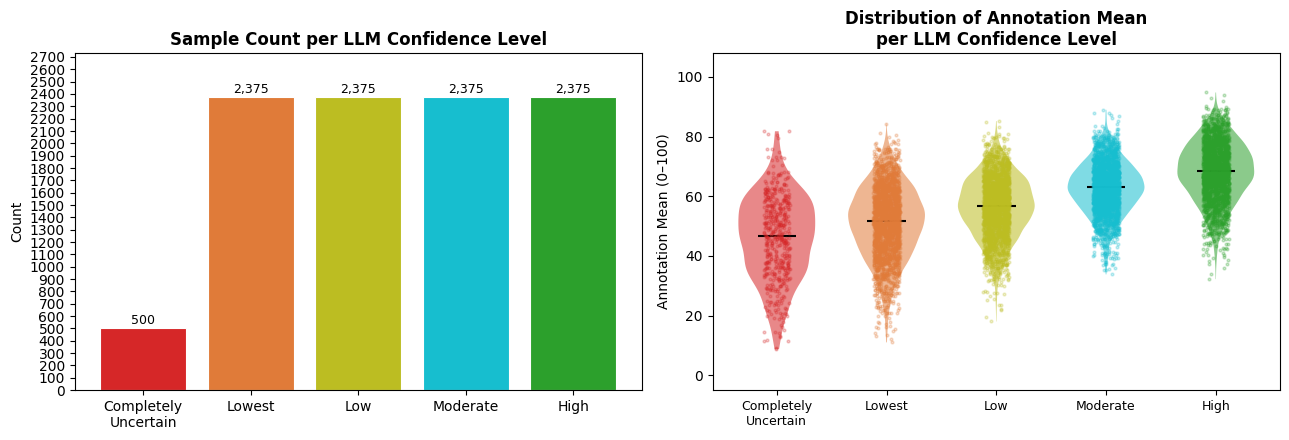

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── left: sample counts per level ─────────────────────────────────────────────
counts = bench["llm_confidence_level"].value_counts().reindex(LEVEL_ORDER)
colors = [PALETTE[lv] for lv in LEVEL_ORDER]
bars = axes[0].bar(
    [LEVEL_LABELS[l] for l in LEVEL_ORDER],
    counts.values,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                 f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Sample Count per LLM Confidence Level", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.15)
axes[0].yaxis.set_major_locator(mticker.MultipleLocator(100))

# ── right: violin + strip of annotation_mean per level ────────────────────────
from matplotlib.patches import Patch

ax = axes[1]
groups = [bench.loc[bench["llm_confidence_level"] == lv, "annotation_mean"].dropna().values
          for lv in LEVEL_ORDER]

vp = ax.violinplot(groups, positions=range(len(LEVEL_ORDER)),
                   widths=0.7, showmedians=True, showextrema=False)
for body, lv in zip(vp["bodies"], LEVEL_ORDER):
    body.set_facecolor(PALETTE[lv])
    body.set_alpha(0.55)
vp["cmedians"].set_color("black")
vp["cmedians"].set_linewidth(1.5)

for i, (grp, lv) in enumerate(zip(groups, LEVEL_ORDER)):
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(grp))
    ax.scatter(i + jitter, grp, s=4, alpha=0.25, color=PALETTE[lv], zorder=2)

ax.set_xticks(range(len(LEVEL_ORDER)))
ax.set_xticklabels([LEVEL_LABELS[l] for l in LEVEL_ORDER], fontsize=9)
ax.set_ylabel("Annotation Mean (0–100)")
ax.set_title("Distribution of Annotation Mean\nper LLM Confidence Level", fontweight="bold")
ax.set_ylim(-5, 108)
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))

fig.tight_layout()
plt.savefig("figs/linguistic_benchmark_stats.pdf", bbox_inches="tight")
plt.show()

## 2 · Aggregated Hedging Lexicon — Score Distributions for Sampled Expressions

In [48]:
# lexicon already has per-word count and mean; sort low → high
expr_stats = lexicon.set_index("hedging_word").sort_values("mean")

# pick 16 words spread across the confidence spectrum
n_pick = 12
step = max(1, len(expr_stats) // n_pick)
sampled_exprs = expr_stats.iloc[::step].index.tolist()[:n_pick]
sampled_exprs = expr_stats.loc[sampled_exprs].sort_values("mean").index.tolist()

print(f"Selected {len(sampled_exprs)} expressions:")
for e in sampled_exprs:
    row = expr_stats.loc[e]
    print(f"  {e!r:35s}  n={int(row['count']):3d}  mean={row['mean']:.3f}")

Selected 12 expressions:
  'I am unable to answer'              n=  3  mean=0.020
  'correct me if I am wrong'           n=  3  mean=0.207
  'may be'                             n=  6  mean=0.288
  'there is a chance that'             n= 30  mean=0.340
  'a bit'                              n=  3  mean=0.377
  "I'd say"                            n=149  mean=0.556
  'may'                                n= 73  mean=0.622
  'quite likely'                       n= 10  mean=0.678
  'in all likelihood'                  n=  7  mean=0.696
  'highly probable'                    n= 10  mean=0.708
  'apparently'                         n=  4  mean=0.725
  'it is clear that'                   n= 15  mean=0.924


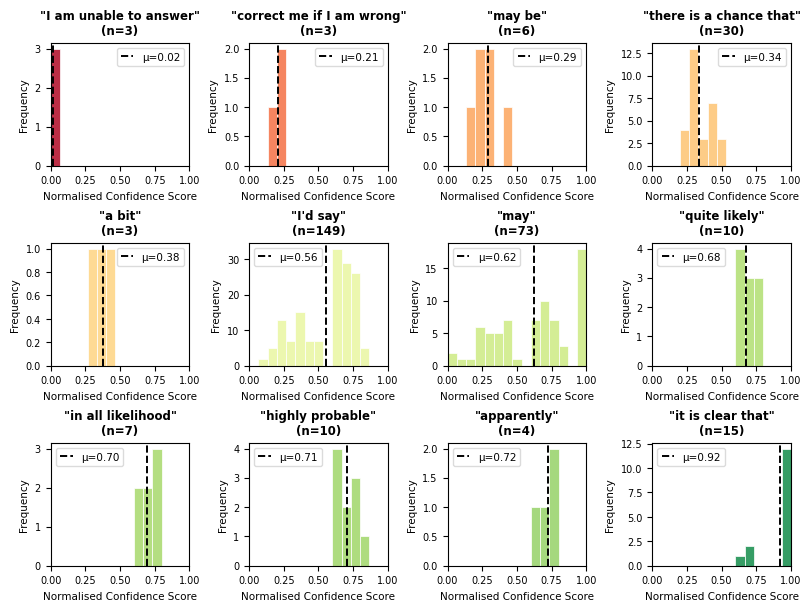

In [50]:
NCOLS = 4
NROWS = (len(sampled_exprs) + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(8, 6),
                         constrained_layout=True)
axes_flat = axes.flatten()

cmap = plt.get_cmap("RdYlGn")

for ax, expr in zip(axes_flat, sampled_exprs):
    scores = np.array(expr_stats.loc[expr, "all_scores"])
    mean_val = expr_stats.loc[expr, "mean"]   # precomputed, scores are 0–1
    color = cmap(mean_val)

    ax.hist(scores, bins=15, range=(0, 1), color=color, edgecolor="white",
            linewidth=0.6, alpha=0.85)
    ax.axvline(mean_val, color="black", lw=1.4, linestyle="--", label=f"μ={mean_val:.2f}")
    ax.legend(fontsize=7.5, handlelength=1.2, framealpha=0.7)

    ax.set_title(f'"{expr}"\n(n={int(expr_stats.loc[expr, "count"])})',
                 fontsize=8.5, fontweight="bold")
    ax.set_xlabel("Normalised Confidence Score", fontsize=7.5)
    ax.set_ylabel("Frequency", fontsize=7.5)
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=7)

for ax in axes_flat[len(sampled_exprs):]:
    ax.set_visible(False)

plt.savefig("figs/human_lc_benchmark_samples.pdf", dpi=300, bbox_inches="tight")
plt.show()